In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)

In [ ]:
import numpy as np
import pandas as pd
import os
import zipfile

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Upload dataset (ZIP file)
uploaded = files.upload()

# Extract dataset
for file_name in uploaded.keys():
    if file_name.endswith(".zip"):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall("/content/dataset")

print("Dataset uploaded and extracted successfully!")

Saving RAVDESS_Audio_Song.zip to RAVDESS_Audio_Song (2).zip
Dataset uploaded and extracted successfully!


In [ ]:
# Dataset path
extract_path = "/content/dataset"

In [ ]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful"
}

paths = []
labels = []

for root, dirs, files_ in os.walk(extract_path):
    for file in files_:
        if file.endswith(".wav") and not file.startswith("._") and "__MACOSX" not in root:
            parts = file.split("-")
            if len(parts) >= 3:
                emotion_code = parts[2]
                if emotion_code in emotion_map:
                    paths.append(os.path.join(root, file))
                    labels.append(emotion_map[emotion_code])

df = pd.DataFrame({
    "speech": paths,
    "label": labels
})

print(df.head())
print(df.shape)
print(df["label"].value_counts())

                                              speech    label
0  /content/dataset/RAVDESS_Audio_Song/Actor_03/0...    angry
1  /content/dataset/RAVDESS_Audio_Song/Actor_03/0...  neutral
2  /content/dataset/RAVDESS_Audio_Song/Actor_03/0...    angry
3  /content/dataset/RAVDESS_Audio_Song/Actor_03/0...  fearful
4  /content/dataset/RAVDESS_Audio_Song/Actor_03/0...     calm
(176, 2)
label
angry      32
fearful    32
happy      32
calm       32
sad        32
neutral    16
Name: count, dtype: int64


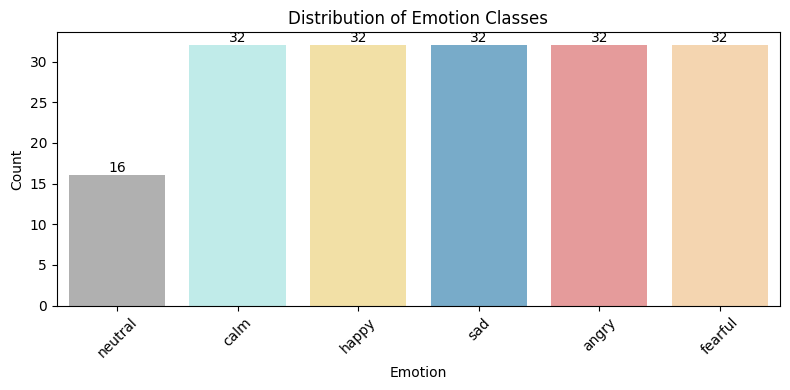

In [ ]:
order = ["neutral", "calm", "happy", "sad", "angry", "fearful"]

colors = [
    "#B0B0B0",
    "#B9F2F0",
    "#FFE699",
    "#6BAED6",
    "#F28E8E",
    "#FFD6A5"
]

plt.figure(figsize=(8,4))
ax = sns.countplot(data=df, x="label", order=order, palette=colors)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_distribution_emotions.png", dpi=300)
plt.show()

Dataset

In [ ]:
from graphviz import Digraph
import os

dot = Digraph(format='png')
dot.attr(rankdir='TB')

dot.node("dataset", "dataset")

ravdess_path = None

for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        if d == "RAVDESS_Audio_Song":
            ravdess_path = os.path.join(root, d)
            break
    if ravdess_path:
        break

if ravdess_path:
    dot.node("RAVDESS_Audio_Song", "RAVDESS_Audio_Song")
    dot.edge("dataset", "RAVDESS_Audio_Song")

    actor_dirs = sorted([
        d for d in os.listdir(ravdess_path)
        if os.path.isdir(os.path.join(ravdess_path, d)) and d.startswith("Actor_")
    ])[:3]

    for actor in actor_dirs:
        actor_path = os.path.join(ravdess_path, actor)
        dot.node(actor, actor)
        dot.edge("RAVDESS_Audio_Song", actor)

        wav_files = sorted([
            f for f in os.listdir(actor_path)
            if f.endswith(".wav")
        ])[:3]

        for wav in wav_files:
            wav_node = f"{actor}_{wav}"
            dot.node(wav_node, wav, shape="note")
            dot.edge(actor, wav_node)

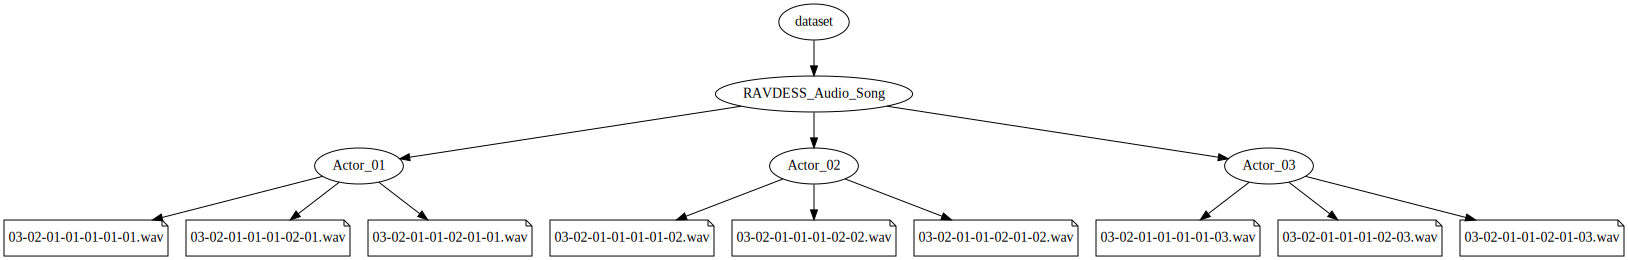

In [ ]:
display(dot)

sample Dataset Audio File Structure / Sample Waveform

In [ ]:
sample_path = df["speech"].iloc[0]
print("Using sample:", sample_path)
y, sr = librosa.load(sample_path, sr=None)

Using sample: /content/dataset/RAVDESS_Audio_Song/Actor_03/03-02-05-01-02-01-03.wav


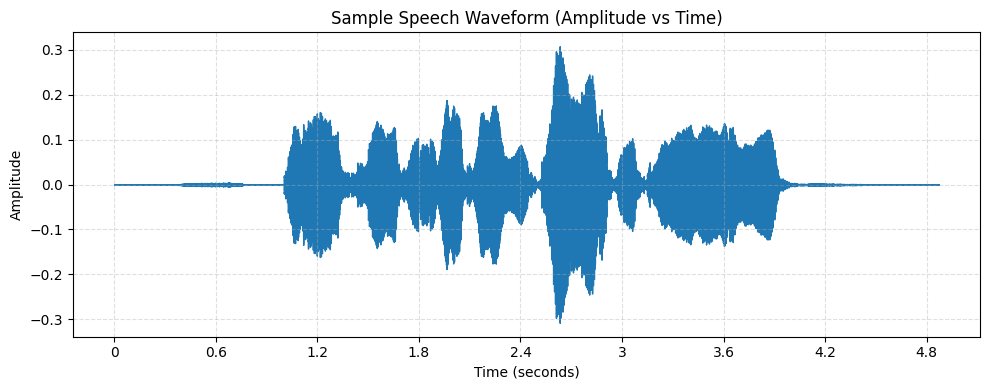

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)

plt.title("Sample Speech Waveform (Amplitude vs Time)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("waveform", dpi=300)
plt.show()

sample Audio Waveform Before and After Processing

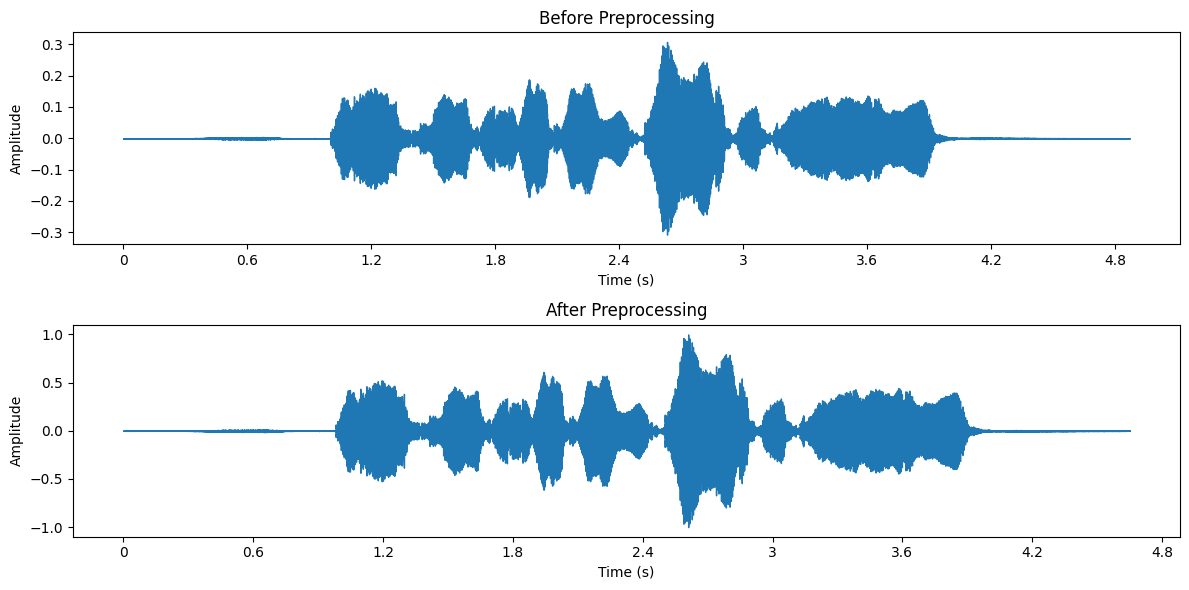

In [ ]:
y_trimmed, _ = librosa.effects.trim(y)
y_processed = librosa.util.normalize(y_trimmed)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Before Preprocessing")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
librosa.display.waveshow(y_processed, sr=sr)
plt.title("After Preprocessing")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.savefig("audio_waveform_before_after.png", dpi=300)
plt.show()

SAMPLE MFCC Feature Visualization

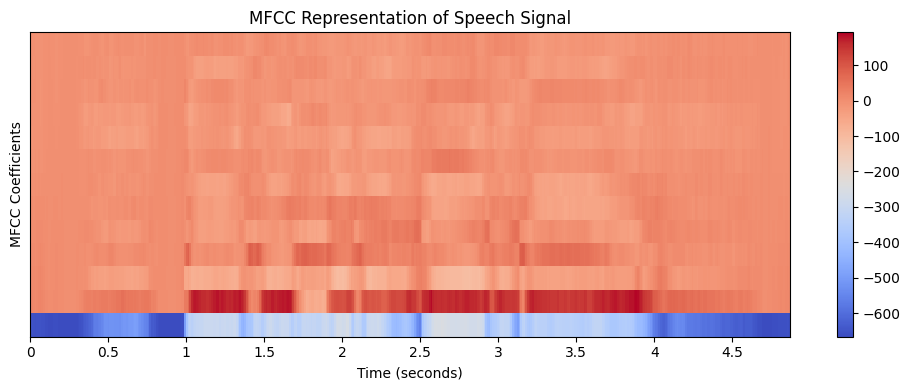

In [ ]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)

plt.colorbar()
plt.title("MFCC Representation of Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficients")

plt.tight_layout()
plt.savefig("mfcc.png", dpi=300)
plt.show()

sample spectogram

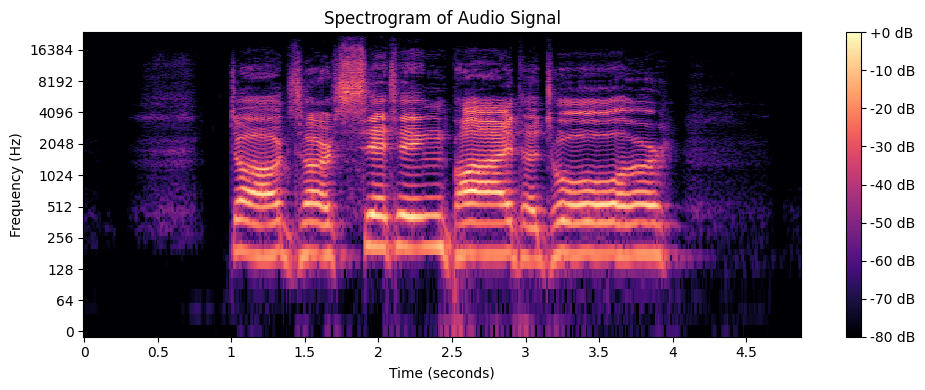

In [ ]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis='time',
    y_axis='log',
    cmap='magma'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Audio Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.savefig("fig_4_4.png", dpi=300)
plt.show()

waveform and spectogram together

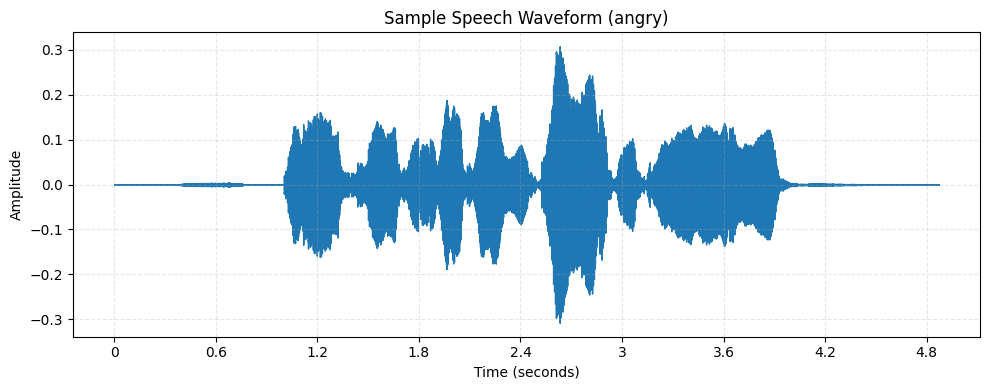

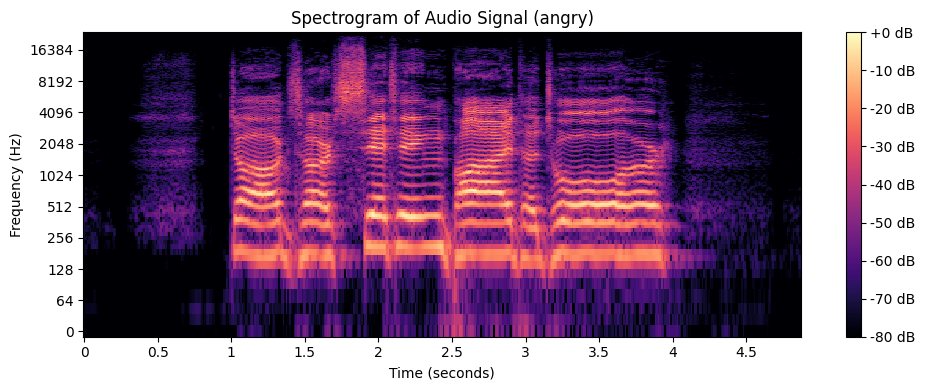

In [ ]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

def waveplot(data, sr, emotion=None):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(data, sr=sr)

    if emotion:
        plt.title(f"Sample Speech Waveform ({emotion})")
    else:
        plt.title("Sample Speech Waveform (Amplitude vs Time)")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig("waveform", dpi=300)
    plt.show()


def spectrogram(data, sr, emotion=None):
    D = librosa.stft(data)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='log',
        cmap='magma'
    )

    plt.colorbar(format='%+2.0f dB')

    if emotion:
        plt.title(f"Spectrogram of Audio Signal ({emotion})")
    else:
        plt.title("Spectrogram of Audio Signal")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")

    plt.tight_layout()
    plt.savefig("spectrogram", dpi=300)
    plt.show()


emotion = df['label'].iloc[0]
path = df['speech'].iloc[0]

data, sr = librosa.load(path, sr=None)

waveplot(data, sr, emotion)
spectrogram(data, sr, emotion)

In [ ]:
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, duration=3, offset=0.5)

        audio, _ = librosa.effects.trim(audio)
        audio = librosa.util.normalize(audio)

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc = np.mean(mfcc.T, axis=0)

        return mfcc

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:
X = []
y = []

for path, label in zip(df["speech"], df["label"]):
    feature = extract_features(path)

    if feature is not None:
        X.append(feature)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (176, 40)
y shape: (176,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (140, 40)
Test shape: (36, 40)


MODELS

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print("\n🔍 Logistic Regression Metrics:")

lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred, average='weighted')
lr_recall = recall_score(y_test, y_pred, average='weighted')
lr_f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)


🔍 Logistic Regression Metrics:
Accuracy : 0.9166666666666666
Precision: 0.9290123456790123
Recall   : 0.9166666666666666
F1 Score : 0.9178078865578867


In [ ]:
lr_mse = mean_squared_error(y_test, y_pred)
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)

print("\n📉 Error Metrics:")
print("MSE  :", lr_mse)
print("MAE  :", lr_mae)
print("RMSE :", lr_rmse)


📉 Error Metrics:
MSE  : 0.25
MAE  : 0.1388888888888889
RMSE : 0.5


In [ ]:
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


📊 Classification Report:

              precision    recall  f1-score   support

       angry       1.00      0.86      0.92         7
        calm       1.00      0.83      0.91         6
     fearful       0.78      1.00      0.88         7
       happy       0.86      0.86      0.86         7
     neutral       1.00      1.00      1.00         3
         sad       1.00      1.00      1.00         6

    accuracy                           0.92        36
   macro avg       0.94      0.92      0.93        36
weighted avg       0.93      0.92      0.92        36



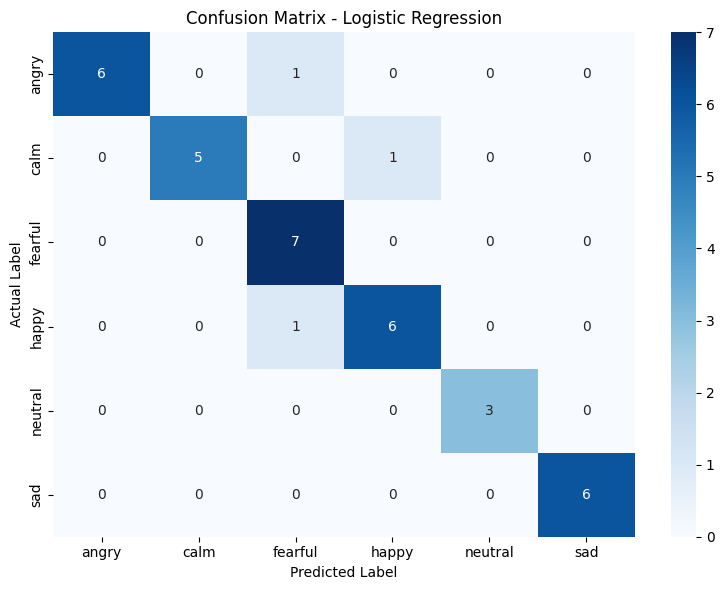

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [ ]:
print("\n🔍 Random Forest Metrics:")

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='weighted')
rf_recall = recall_score(y_test, rf_preds, average='weighted')
rf_f1 = f1_score(y_test, rf_preds, average='weighted')

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)


🔍 Random Forest Metrics:
Accuracy : 0.8055555555555556
Precision: 0.8222222222222222
Recall   : 0.8055555555555556
F1 Score : 0.7963639301874595


In [ ]:
rf_mse = mean_squared_error(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)

print("\n📉 Error Metrics:")
print("MSE  :", rf_mse)
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)


📉 Error Metrics:
MSE  : 0.6111111111111112
MAE  : 0.3333333333333333
RMSE : 0.7817359599705717


In [ ]:
print("\n📊 Classification Report - Random Forest:\n")
print(classification_report(y_test, rf_preds, target_names=encoder.classes_))


📊 Classification Report - Random Forest:

              precision    recall  f1-score   support

       angry       1.00      0.86      0.92         7
        calm       0.75      1.00      0.86         6
     fearful       0.70      1.00      0.82         7
       happy       0.60      0.43      0.50         7
     neutral       1.00      1.00      1.00         3
         sad       1.00      0.67      0.80         6

    accuracy                           0.81        36
   macro avg       0.84      0.83      0.82        36
weighted avg       0.82      0.81      0.80        36



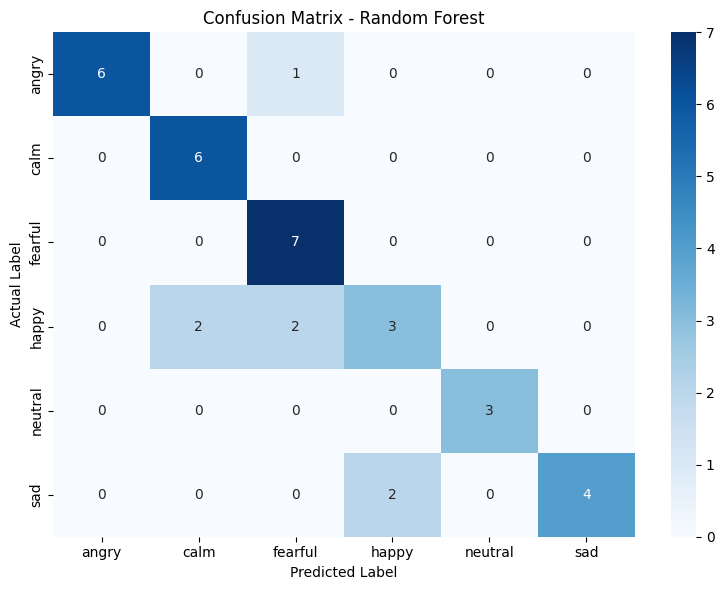

In [ ]:
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train_scaled, y_train)

svm_preds = svm_model.predict(X_test_scaled)

In [ ]:
print("\n🔍 SVM Metrics:")

svm_accuracy = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds, average='weighted')
svm_recall = recall_score(y_test, svm_preds, average='weighted')
svm_f1 = f1_score(y_test, svm_preds, average='weighted')

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)


🔍 SVM Metrics:
Accuracy : 0.9166666666666666
Precision: 0.925925925925926
Recall   : 0.9166666666666666
F1 Score : 0.9163614163614164


In [ ]:
svm_mse = mean_squared_error(y_test, svm_preds)
svm_mae = mean_absolute_error(y_test, svm_preds)
svm_rmse = np.sqrt(svm_mse)

print("\n📉 Error Metrics:")
print("MSE  :", svm_mse)
print("MAE  :", svm_mae)
print("RMSE :", svm_rmse)


📉 Error Metrics:
MSE  : 0.6111111111111112
MAE  : 0.2222222222222222
RMSE : 0.7817359599705717


In [ ]:
print("\n📊 Classification Report:\n")
print(classification_report(y_test, svm_preds, target_names=encoder.classes_))


📊 Classification Report:

              precision    recall  f1-score   support

       angry       1.00      0.86      0.92         7
        calm       1.00      1.00      1.00         6
     fearful       0.83      0.71      0.77         7
       happy       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         3
         sad       0.75      1.00      0.86         6

    accuracy                           0.92        36
   macro avg       0.93      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



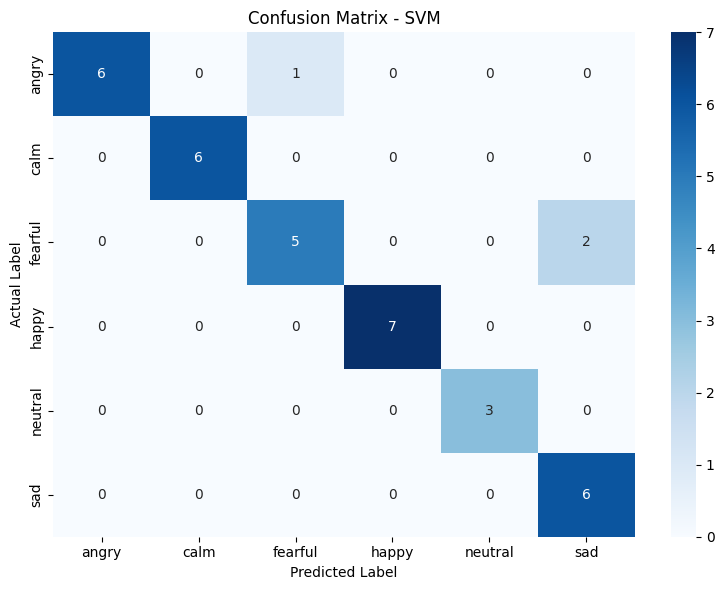

In [ ]:
cm_svm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

XGBOOST

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [ ]:
print("\n⚡ XGBoost Metrics:")

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds, average='weighted')
xgb_recall = recall_score(y_test, xgb_preds, average='weighted')
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)


⚡ XGBoost Metrics:
Accuracy : 0.7222222222222222
Precision: 0.7504629629629629
Recall   : 0.7222222222222222
F1 Score : 0.7060846560846561


In [ ]:
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(xgb_mse)

print("\n📉 Error Metrics:")
print("MSE  :", xgb_mse)
print("MAE  :", xgb_mae)
print("RMSE :", xgb_rmse)


📉 Error Metrics:
MSE  : 1.8888888888888888
MAE  : 0.6666666666666666
RMSE : 1.3743685418725535


In [ ]:
print("\n📊 Classification Report - XGBoost:\n")
print(classification_report(y_test, xgb_preds, target_names=encoder.classes_))


📊 Classification Report - XGBoost:

              precision    recall  f1-score   support

       angry       1.00      0.71      0.83         7
        calm       0.60      1.00      0.75         6
     fearful       0.71      0.71      0.71         7
       happy       0.67      0.29      0.40         7
     neutral       1.00      1.00      1.00         3
         sad       0.62      0.83      0.71         6

    accuracy                           0.72        36
   macro avg       0.77      0.76      0.74        36
weighted avg       0.75      0.72      0.71        36



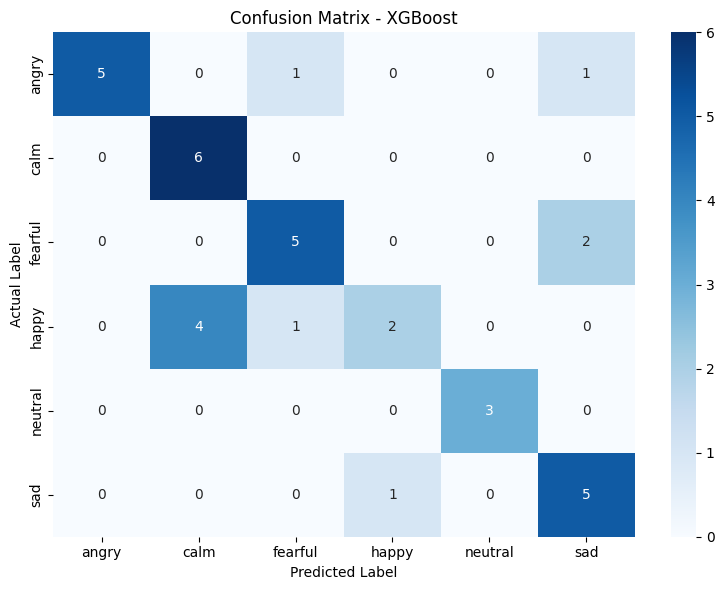

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

Model Comparision Accuracy

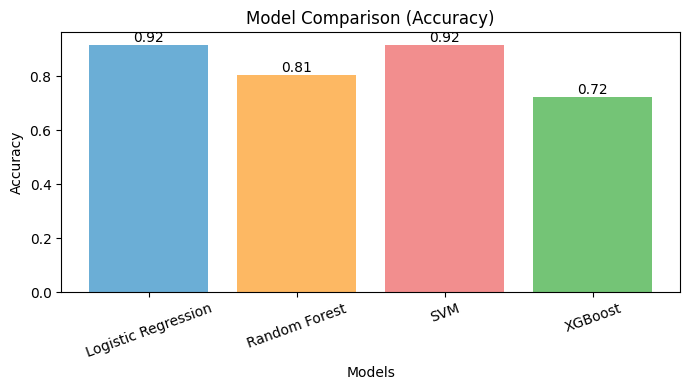

In [ ]:
models = ["Logistic Regression", "Random Forest", "SVM", "XGBoost"]
accuracies = [lr_accuracy, rf_accuracy, svm_accuracy, xgb_accuracy]

colors = ["#6BAED6", "#FDB863", "#F28E8E", "#74C476"]

plt.figure(figsize=(7,4))
bars = plt.bar(models, accuracies, color=colors)

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.xticks(rotation=20)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

Model Comparision

In [ ]:
comparison = pd.DataFrame({
    "Logistic Regression": [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_mse, lr_mae, lr_rmse],
    "Random Forest": [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_mse, rf_mae, rf_rmse],
    "SVM": [svm_accuracy, svm_precision, svm_recall, svm_f1, svm_mse, svm_mae, svm_rmse],
    "XGBoost": [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_mse, xgb_mae, xgb_rmse]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "MSE", "MAE", "RMSE"])

print(comparison)

           Logistic Regression  Random Forest       SVM   XGBoost
Accuracy              0.916667       0.805556  0.916667  0.722222
Precision             0.929012       0.822222  0.925926  0.750463
Recall                0.916667       0.805556  0.916667  0.722222
F1 Score              0.917808       0.796364  0.916361  0.706085
MSE                   0.250000       0.611111  0.611111  1.888889
MAE                   0.138889       0.333333  0.222222  0.666667
RMSE                  0.500000       0.781736  0.781736  1.374369


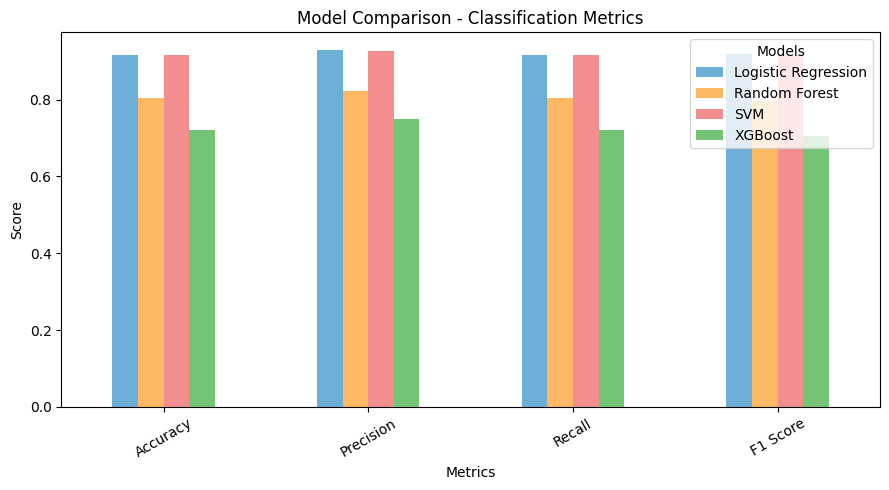

In [ ]:
classification_metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#6BAED6", "#FDB863", "#F28E8E", "#74C476"]

comparison.loc[classification_metrics].plot(
    kind='bar',
    figsize=(9, 5),
    color=colors
)

plt.title("Model Comparison - Classification Metrics")
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.xticks(rotation=30)
plt.legend(title="Models")
plt.tight_layout()
plt.show()

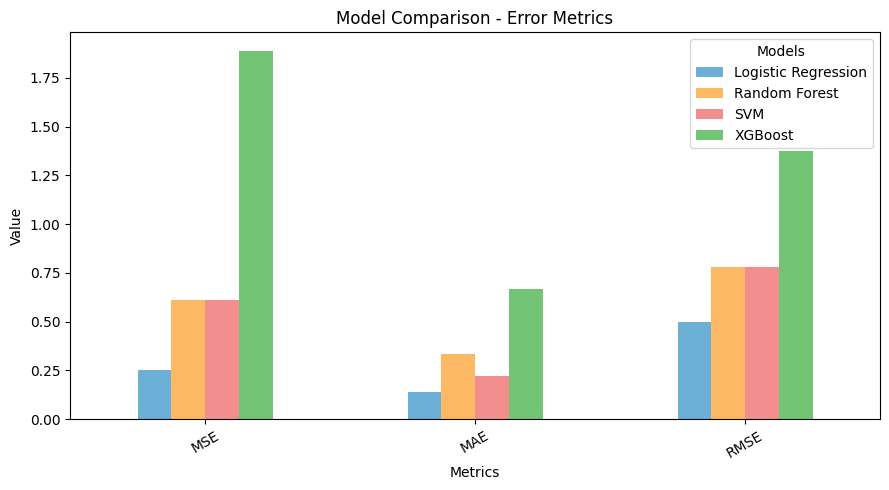

In [ ]:
error_metrics = ["MSE", "MAE", "RMSE"]

comparison.loc[error_metrics].plot(
    kind='bar',
    figsize=(9, 5),
    color=colors
)

plt.title("Model Comparison - Error Metrics")
plt.ylabel("Value")
plt.xlabel("Metrics")
plt.xticks(rotation=30)
plt.legend(title="Models")
plt.tight_layout()
plt.show()

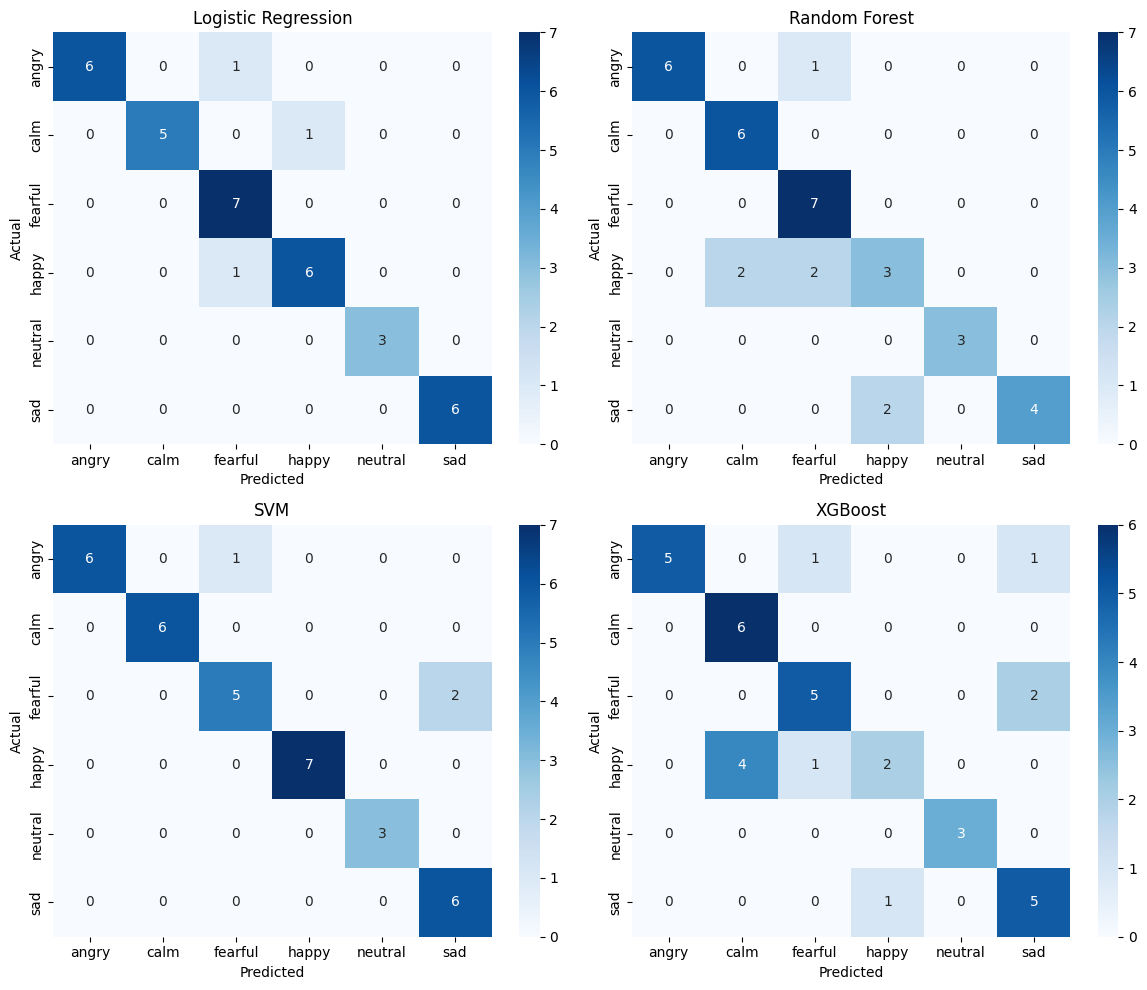

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred)
cm_rf = confusion_matrix(y_test, rf_preds)
cm_svm = confusion_matrix(y_test, svm_preds)
cm_xgb = confusion_matrix(y_test, xgb_preds)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = ["Logistic Regression", "Random Forest", "SVM", "XGBoost"]
cms = [cm_lr, cm_rf, cm_svm, cm_xgb]

for ax, cm, title in zip(axes.flatten(), cms, models):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()